D:\software\ANACONDA\envs\RFR\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
D:\software\ANACONDA\envs\RFR\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
D:\software\ANACONDA\envs\RFR\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


Mean Squared Error_train: 0.009749795638200632
Root Mean Squared Error_train: 0.09874105345903816
Mean Absolute Error_train: 0.07134502016224632
R^2 Score_train: 0.9966427613945691
Mean Squared Error_test: 0.07452705173206181
Root Mean Squared Error_test: 0.2729964317203831
Mean Absolute Error_test: 0.194397837162584
R^2 Score_test: 0.9745393411523857

train set (95% CI):
R2: 0.9966 (95% CI: [0.9964, 0.9969])
RMSE: 0.0987 (95% CI: [0.0957, 0.1020])
MAE: 0.0713 (95% CI: [0.0696, 0.0733])
MSE: 0.0097 (95% CI: [0.0092, 0.0104])

test set (95% CI):
R2: 0.9745 (95% CI: [0.9709, 0.9777])
RMSE: 0.2730 (95% CI: [0.2556, 0.2914])
MAE: 0.1944 (95% CI: [0.1833, 0.2052])
MSE: 0.0745 (95% CI: [0.0653, 0.0849])


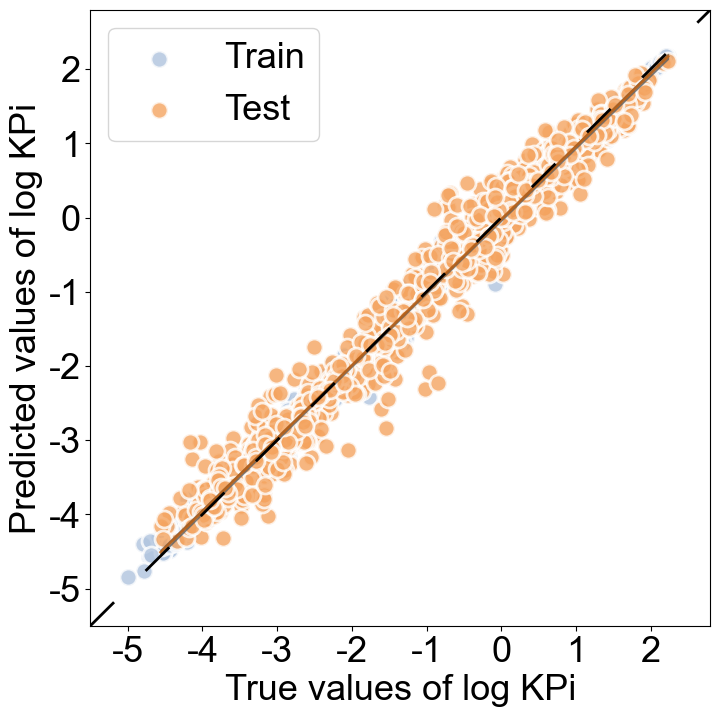

Slope_train: 0.9912736903315327
Intercept_train: -0.007181973776612116
Slope_test: 0.9835832664732789
Intercept_test: -0.02466575262194204


In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.legend as legend
from scipy.stats import linregress, t


df = pd.read_excel('preprocessed_input_data_6_features.xlsx')

target_column = 'log KPi'

y = df[target_column]
X = df.drop(columns=[target_column]) 

 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

RFR = RandomForestRegressor(n_estimators=180, max_depth=130, max_features=8, min_samples_split=2, min_samples_leaf=1, random_state=42)
RFR.fit(X_train, y_train)
 
 
y_train_pred = RFR.predict(X_train)
y_test_pred = RFR.predict(X_test)
 

mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred) 
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)   
print(f"Mean Squared Error_train: {mse_train}")
print(f"Root Mean Squared Error_train: {rmse_train}") 
print(f"Mean Absolute Error_train: {mae_train}")
print(f"R^2 Score_train: {r2_train}")

mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred) 
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)   
print(f"Mean Squared Error_test: {mse_test}")
print(f"Root Mean Squared Error_test: {rmse_test}") 
print(f"Mean Absolute Error_test: {mae_test}")
print(f"R^2 Score_test: {r2_test}")

def bootstrap_metrics(model, X, y, n_iterations=1000):
    
    r2_scores = []
    rmse_scores = []
    mae_scores = []
    mse_scores = []
    
    y_pred = model.predict(X)
    
    r2_orig = r2_score(y, y_pred)
    mse_orig = mean_squared_error(y, y_pred)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = mean_absolute_error(y, y_pred)
    
    n = len(y)
    
    for _ in range(n_iterations):
        
        indices = np.random.choice(n, n, replace=True)
        
        if isinstance(X, pd.DataFrame):
            X_bs = X.iloc[indices]
        else:
            X_bs = X[indices]
        
        if isinstance(y, pd.Series):
            y_bs = y.iloc[indices]
        else:
            y_bs = y[indices]
        
        y_pred_bs = model.predict(X_bs)
        
        r2 = r2_score(y_bs, y_pred_bs)
        mse = mean_squared_error(y_bs, y_pred_bs)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_bs, y_pred_bs)
        
        r2_scores.append(r2)
        rmse_scores.append(rmse)
        mae_scores.append(mae)
        mse_scores.append(mse)
    
    def calc_ci(scores):
        lower = np.percentile(scores, 2.5)
        upper = np.percentile(scores, 97.5)
        return (lower, upper)
    
    return {
        'R2': {'value': r2_orig, 'ci': calc_ci(r2_scores)},
        'RMSE': {'value': rmse_orig, 'ci': calc_ci(rmse_scores)},
        'MAE': {'value': mae_orig, 'ci': calc_ci(mae_scores)},
        'MSE': {'value': mse_orig, 'ci': calc_ci(mse_scores)}
    }

train_metrics = bootstrap_metrics(RFR, X_train, y_train, n_iterations=1000)

test_metrics = bootstrap_metrics(RFR, X_test, y_test, n_iterations=1000)

def print_metrics(metrics, dataset_name):
    print(f"\n{dataset_name} (95% CI):")
    for metric, data in metrics.items():
        value = data['value']
        lower, upper = data['ci']
        print(f"{metric}: {value:.4f} (95% CI: [{lower:.4f}, {upper:.4f}])")

print_metrics(train_metrics, "train set")
print_metrics(test_metrics, "test set")


fig, ax = plt.subplots(figsize=(8, 8))  
 
ax.scatter(y_train, y_train_pred, label='Train', color='#B0C4DE', alpha=0.8, s=150, edgecolors='white', linewidths=2)  

ax.scatter(y_test, y_test_pred, label='Test', color='#F4A460', alpha=0.8, s=150, edgecolors='white', linewidths=2)  

ax.set_xlim(-5.5, 2.8)  
ax.set_ylim(-5.5, 2.8)
 
ax.set_xticks([-5, -4, -3, -2, -1, 0, 1, 2])  
ax.set_xticklabels([-5, -4, -3, -2, -1, 0, 1, 2], fontsize=26, fontname='Arial')  
ax.set_yticks([-5, -4, -3, -2, -1, 0, 1, 2])  
ax.set_yticklabels([-5, -4, -3, -2, -1, 0, 1, 2], fontsize=26, fontname='Arial')


ax.set_xlabel('True values of log KPi', fontsize=26, fontname = 'Arial')  
ax.set_ylabel('Predicted values of log KPi', fontsize=26, fontname = 'Arial')  
  

legend_props = matplotlib.font_manager.FontProperties(family= 'Arial', size=26)
ax.legend(prop=legend_props)

slope_train, intercept_train, r_value_train, p_value_train, std_err_train = linregress(y_train, y_train_pred) 
slope_test, intercept_test, r_value_test, p_value_test, std_err_test = linregress(y_test, y_test_pred)

x_sorted = np.sort(y_test)

y_fit_sorted = slope_test * x_sorted + intercept_test


residuals = y_test - y_test_pred
dof = len(y_test) - 2
s_err = np.sqrt(np.sum(residuals**2) / dof)


t_val = t.ppf(0.975, dof) 


conf_interval = t_val * s_err * np.sqrt(1/len(y_test) + (x_sorted - np.mean(y_test))**2 / np.sum((y_test - np.mean(y_test))**2))


lower_bound = y_fit_sorted - conf_interval
upper_bound = y_fit_sorted + conf_interval


ax.fill_between(x_sorted, lower_bound, upper_bound, color='#5F5F5F', alpha=0.7, label='95% Confidence Interval')


ax.plot(x_sorted, y_fit_sorted, color='#BF5E0D', linestyle='solid', alpha=0.8, linewidth=2, label='Regression Line')


x_line = np.linspace(-5.5, 2.8, 100)
y_line = x_line

line, =plt.plot(x_line, y_line, color='#000000', linestyle='--', linewidth=2)
line.set_dashes([12, 16])

plt.show()

print (f"Slope_train: {slope_train}")
print (f"Intercept_train: {intercept_train}")
print (f"Slope_test: {slope_test}")
print (f"Intercept_test: {intercept_test}")

Mean Squared Error_train: 0.1042194952864945
Root Mean Squared Error_train: 0.3228304435558928
Mean Absolute Error_train: 0.24418497922687865
R^2 Score_train: 0.9641131233927158
Mean Squared Error_test: 0.1465435294192696
Root Mean Squared Error_test: 0.38281004351932774
Mean Absolute Error_test: 0.29105374685202023
R^2 Score_test: 0.9499363691148912

train set (95% CI):
R2: 0.9641 (95% CI: [0.9617, 0.9663])
RMSE: 0.3228 (95% CI: [0.3133, 0.3325])
MAE: 0.2442 (95% CI: [0.2381, 0.2505])
MSE: 0.1042 (95% CI: [0.0982, 0.1106])

test set (95% CI):
R2: 0.9499 (95% CI: [0.9441, 0.9551])
RMSE: 0.3828 (95% CI: [0.3633, 0.4040])
MAE: 0.2911 (95% CI: [0.2777, 0.3056])
MSE: 0.1465 (95% CI: [0.1320, 0.1632])


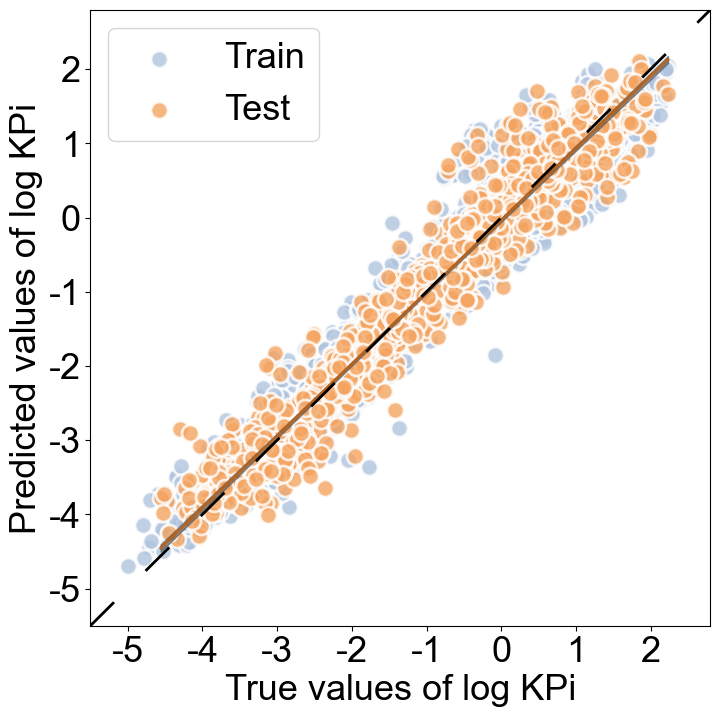

Slope_train: 0.9656046977776179
Intercept_train: -0.03440450336041834
Slope_test: 0.9690413773483745
Intercept_test: -0.033570696948388656


In [2]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.legend as legend
from scipy.stats import linregress, t


df = pd.read_excel('preprocessed_input_data_6_features.xlsx')


target_column = 'log KPi'


y = df[target_column]
X = df.drop(columns=[target_column]) 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svr = SVR(C=1200, epsilon=0.2, gamma=3)
svr.fit(X_train, y_train)
 

y_train_pred = svr.predict(X_train)
y_test_pred = svr.predict(X_test)
 

mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred) 
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)   
print(f"Mean Squared Error_train: {mse_train}")
print(f"Root Mean Squared Error_train: {rmse_train}") 
print(f"Mean Absolute Error_train: {mae_train}")
print(f"R^2 Score_train: {r2_train}")

mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred) 
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)   
print(f"Mean Squared Error_test: {mse_test}")
print(f"Root Mean Squared Error_test: {rmse_test}") 
print(f"Mean Absolute Error_test: {mae_test}")
print(f"R^2 Score_test: {r2_test}")


def bootstrap_metrics(model, X, y, n_iterations=1000):
    
    r2_scores = []
    rmse_scores = []
    mae_scores = []
    mse_scores = []
    
    y_pred = model.predict(X)
    
    r2_orig = r2_score(y, y_pred)
    mse_orig = mean_squared_error(y, y_pred)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = mean_absolute_error(y, y_pred)
    
    n = len(y)
    
    for _ in range(n_iterations):
        
        indices = np.random.choice(n, n, replace=True)
        
        if isinstance(X, pd.DataFrame):
            X_bs = X.iloc[indices]
        else:
            X_bs = X[indices]
        
        if isinstance(y, pd.Series):
            y_bs = y.iloc[indices]
        else:
            y_bs = y[indices]
        
        y_pred_bs = model.predict(X_bs)
        
        r2 = r2_score(y_bs, y_pred_bs)
        mse = mean_squared_error(y_bs, y_pred_bs)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_bs, y_pred_bs)
        
        r2_scores.append(r2)
        rmse_scores.append(rmse)
        mae_scores.append(mae)
        mse_scores.append(mse)
    
    def calc_ci(scores):
        lower = np.percentile(scores, 2.5)
        upper = np.percentile(scores, 97.5)
        return (lower, upper)
    
    return {
        'R2': {'value': r2_orig, 'ci': calc_ci(r2_scores)},
        'RMSE': {'value': rmse_orig, 'ci': calc_ci(rmse_scores)},
        'MAE': {'value': mae_orig, 'ci': calc_ci(mae_scores)},
        'MSE': {'value': mse_orig, 'ci': calc_ci(mse_scores)}
    }

train_metrics = bootstrap_metrics(svr, X_train, y_train, n_iterations=1000)

test_metrics = bootstrap_metrics(svr, X_test, y_test, n_iterations=1000)

def print_metrics(metrics, dataset_name):
    print(f"\n{dataset_name} (95% CI):")
    for metric, data in metrics.items():
        value = data['value']
        lower, upper = data['ci']
        print(f"{metric}: {value:.4f} (95% CI: [{lower:.4f}, {upper:.4f}])")

print_metrics(train_metrics, "train set")
print_metrics(test_metrics, "test set")


fig, ax = plt.subplots(figsize=(8, 8))  

ax.scatter(y_train, y_train_pred, label='Train', color='#B0C4DE', alpha=0.8, s=150, edgecolors='white', linewidths=2)  

ax.scatter(y_test, y_test_pred, label='Test', color='#F4A460', alpha=0.8, s=150, edgecolors='white', linewidths=2)  
  

ax.set_xlim(-5.5, 2.8)  
ax.set_ylim(-5.5, 2.8)
 
ax.set_xticks([-5, -4, -3, -2, -1, 0, 1, 2])  
ax.set_xticklabels([-5, -4, -3, -2, -1, 0, 1, 2], fontsize=26, fontname='Arial')  
ax.set_yticks([-5, -4, -3, -2, -1, 0, 1, 2])  
ax.set_yticklabels([-5, -4, -3, -2, -1, 0, 1, 2], fontsize=26, fontname='Arial')


ax.set_xlabel('True values of log KPi', fontsize=26, fontname = 'Arial')  
ax.set_ylabel('Predicted values of log KPi', fontsize=26, fontname = 'Arial')  
  
 
legend_props = matplotlib.font_manager.FontProperties(family= 'Arial', size=26)
ax.legend(prop=legend_props)

slope_train, intercept_train, r_value_train, p_value_train, std_err_train = linregress(y_train, y_train_pred) 
slope_test, intercept_test, r_value_test, p_value_test, std_err_test = linregress(y_test, y_test_pred)

x_sorted = np.sort(y_test)

y_fit_sorted = slope_test * x_sorted + intercept_test


residuals = y_test - y_test_pred
dof = len(y_test) - 2
s_err = np.sqrt(np.sum(residuals**2) / dof)


t_val = t.ppf(0.975, dof) 


conf_interval = t_val * s_err * np.sqrt(1/len(y_test) + (x_sorted - np.mean(y_test))**2 / np.sum((y_test - np.mean(y_test))**2))


lower_bound = y_fit_sorted - conf_interval
upper_bound = y_fit_sorted + conf_interval


ax.fill_between(x_sorted, lower_bound, upper_bound, color='#5F5F5F', alpha=0.7, label='95% Confidence Interval')


ax.plot(x_sorted, y_fit_sorted, color='#BF5E0D', linestyle='solid', alpha=0.8, linewidth=2, label='Regression Line')

x_line = np.linspace(-5.5, 2.8, 100)
y_line = x_line

line, =plt.plot(x_line, y_line, color='#000000', linestyle='--', linewidth=2)
line.set_dashes([12, 16])

plt.show()  

print (f"Slope_train: {slope_train}")
print (f"Intercept_train: {intercept_train}")
print (f"Slope_test: {slope_test}")
print (f"Intercept_test: {intercept_test}")

38/38 [==============================] - 0s 642us/step
Mean Squared Error_train: 0.11573473494949188
Root Mean Squared Error_train: 0.3401980819309419
Mean Absolute Error_train: 0.263472655240316
R^2 Score_train: 0.9601479728826957
Mean Squared Error_test: 0.15095974276104274
Root Mean Squared Error_test: 0.3885353816077022
Mean Absolute Error_test: 0.30109557706761164
R^2 Score_test: 0.9484276592078174
38/38 [==============================] - 0s 858us/step

train set (95% CI):
R2: 0.9601 (95% CI: [0.9580, 0.9623])
RMSE: 0.3402 (95% CI: [0.3319, 0.3478])
MAE: 0.2635 (95% CI: [0.2574, 0.2693])
MSE: 0.1157 (95% CI: [0.1102, 0.1210])

test set (95% CI):
R2: 0.9484 (95% CI: [0.9429, 0.9538])
RMSE: 0.3885 (95% CI: [0.3704, 0.4058])
MAE: 0.3011 (95% CI: [0.2873, 0.3140])
MSE: 0.1510 (95% CI: [0.1372, 0.1647])


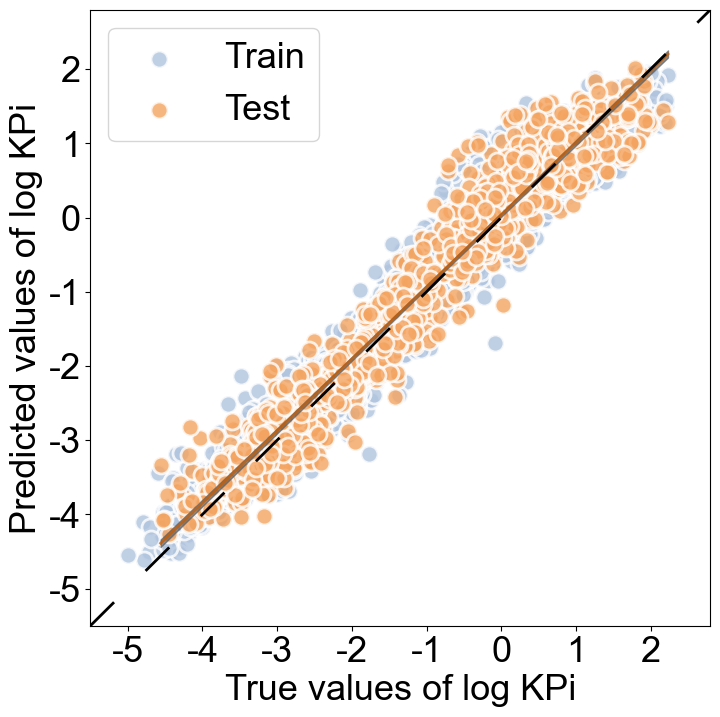

Slope_train: 0.96729606296959
Intercept_train: 0.038595975816951955
Slope_test: 0.9706001900248243
Intercept_test: 0.03711135541472421


In [4]:
import random
import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)  
tf.random.set_seed(42)

import pandas as pd
import os
from tensorflow import keras
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Dense  
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.legend as legend
from scipy.stats import linregress, t

os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'


df = pd.read_excel('preprocessed_input_data_6_features.xlsx')


target_column = 'log KPi'


y = df[target_column]
X = df.drop(columns=[target_column]) 

 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


DNN = Sequential([  
  Dense(64, activation='relu', input_shape=(X.shape[1],)),   
  Dense(32, activation='relu'),
  Dense(1)
])  


DNN.compile(optimizer=Adam(learning_rate=0.001), loss='mse')  

  
DNN.fit(X_train, y_train, epochs=1000, batch_size=64, shuffle=False, verbose=0)  
  
  
y_train_pred = DNN.predict(X_train)
y_test_pred = DNN.predict(X_test)
 

y_train_pred_flattened = y_train_pred.flatten()
y_test_pred_flattened = y_test_pred.flatten()

  
mse_train = mean_squared_error(y_train, y_train_pred_flattened)
mae_train = mean_absolute_error(y_train, y_train_pred_flattened) 
r2_train = r2_score(y_train, y_train_pred_flattened)
rmse_train = np.sqrt(mse_train)   
print(f"Mean Squared Error_train: {mse_train}")
print(f"Root Mean Squared Error_train: {rmse_train}") 
print(f"Mean Absolute Error_train: {mae_train}")
print(f"R^2 Score_train: {r2_train}")

mse_test = mean_squared_error(y_test, y_test_pred_flattened)
mae_test = mean_absolute_error(y_test, y_test_pred_flattened) 
r2_test = r2_score(y_test, y_test_pred_flattened)
rmse_test = np.sqrt(mse_test)   
print(f"Mean Squared Error_test: {mse_test}")
print(f"Root Mean Squared Error_test: {rmse_test}") 
print(f"Mean Absolute Error_test: {mae_test}")
print(f"R^2 Score_test: {r2_test}")

 
def bootstrap_metrics(model, X, y, n_iterations=1000):
    
    r2_scores = []
    rmse_scores = []
    mae_scores = []
    mse_scores = []
    
    y_pred = model.predict(X)
    y_pred_flattened = y_pred.flatten()
    
    r2_orig = r2_score(y, y_pred_flattened)
    mse_orig = mean_squared_error(y, y_pred_flattened)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = mean_absolute_error(y, y_pred_flattened)
    
    n = len(y)
    
    for _ in range(n_iterations):
        
        indices = np.random.choice(n, n, replace=True)
        
        if isinstance(X, pd.DataFrame):
            X_bs = X.iloc[indices]
        else:
            X_bs = X[indices]
        
        if isinstance(y, pd.Series):
            y_bs = y.iloc[indices]
        else:
            y_bs = y[indices]
        
        y_pred_bs = model.predict(X_bs)
        y_pred_bs_flattened = y_pred_bs.flatten()
        
        r2 = r2_score(y_bs, y_pred_bs_flattened)
        mse = mean_squared_error(y_bs, y_pred_bs_flattened)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_bs, y_pred_bs_flattened)
        
        r2_scores.append(r2)
        rmse_scores.append(rmse)
        mae_scores.append(mae)
        mse_scores.append(mse)
    
    def calc_ci(scores):
        lower = np.percentile(scores, 2.5)
        upper = np.percentile(scores, 97.5)
        return (lower, upper)
    
    return {
        'R2': {'value': r2_orig, 'ci': calc_ci(r2_scores)},
        'RMSE': {'value': rmse_orig, 'ci': calc_ci(rmse_scores)},
        'MAE': {'value': mae_orig, 'ci': calc_ci(mae_scores)},
        'MSE': {'value': mse_orig, 'ci': calc_ci(mse_scores)}
    }

train_metrics = bootstrap_metrics(DNN, X_train, y_train, n_iterations=1000)

test_metrics = bootstrap_metrics(DNN, X_test, y_test, n_iterations=1000)

def print_metrics(metrics, dataset_name):
    print(f"\n{dataset_name} (95% CI):")
    for metric, data in metrics.items():
        value = data['value']
        lower, upper = data['ci']
        print(f"{metric}: {value:.4f} (95% CI: [{lower:.4f}, {upper:.4f}])")

print_metrics(train_metrics, "train set")
print_metrics(test_metrics, "test set")


fig, ax = plt.subplots(figsize=(8, 8))  

ax.scatter(y_train, y_train_pred_flattened, label='Train', color='#B0C4DE', alpha=0.8, s=150, edgecolors='white', linewidths=2)  
  
 
ax.scatter(y_test, y_test_pred_flattened, label='Test', color='#F4A460', alpha=0.8, s=150, edgecolors='white', linewidths=2)  


ax.set_xlim(-5.5, 2.8)  
ax.set_ylim(-5.5, 2.8)
 
ax.set_xticks([-5, -4, -3, -2, -1, 0, 1, 2])  
ax.set_xticklabels([-5, -4, -3, -2, -1, 0, 1, 2], fontsize=26, fontname='Arial')  
ax.set_yticks([-5, -4, -3, -2, -1, 0, 1, 2])  
ax.set_yticklabels([-5, -4, -3, -2, -1, 0, 1, 2], fontsize=26, fontname='Arial')


ax.set_xlabel('True values of log KPi', fontsize=26, fontname = 'Arial')  
ax.set_ylabel('Predicted values of log KPi', fontsize=26, fontname = 'Arial')  
  
 
legend_props = matplotlib.font_manager.FontProperties(family= 'Arial', size=26)
ax.legend(prop=legend_props)

slope_train, intercept_train, r_value_train, p_value_train, std_err_train = linregress(y_train, y_train_pred_flattened) 
slope_test, intercept_test, r_value_test, p_value_test, std_err_test = linregress(y_test, y_test_pred_flattened)  

x_sorted = np.sort(y_test)

y_fit_sorted = slope_test * x_sorted + intercept_test


residuals = y_test - y_test_pred_flattened
dof = len(y_test) - 2
s_err = np.sqrt(np.sum(residuals**2) / dof)


t_val = t.ppf(0.975, dof) 


conf_interval = t_val * s_err * np.sqrt(1/len(y_test) + (x_sorted - np.mean(y_test))**2 / np.sum((y_test - np.mean(y_test))**2))


lower_bound = y_fit_sorted - conf_interval
upper_bound = y_fit_sorted + conf_interval


ax.fill_between(x_sorted, lower_bound, upper_bound, color='#5F5F5F', alpha=0.7, label='95% Confidence Interval')


ax.plot(x_sorted, y_fit_sorted, color='#BF5E0D', linestyle='solid', alpha=0.8, linewidth=2, label='Regression Line')

x_line = np.linspace(-5.5, 2.8, 100)
y_line = x_line

line, =plt.plot(x_line, y_line, color='#000000', linestyle='--', linewidth=2)
line.set_dashes([12, 16])

plt.show()

print (f"Slope_train: {slope_train}")
print (f"Intercept_train: {intercept_train}")
print (f"Slope_test: {slope_test}")
print (f"Intercept_test: {intercept_test}")

R^2 Score_test: 0.9745393411523857
Root Mean Squared Error_test: 0.2729964317203831


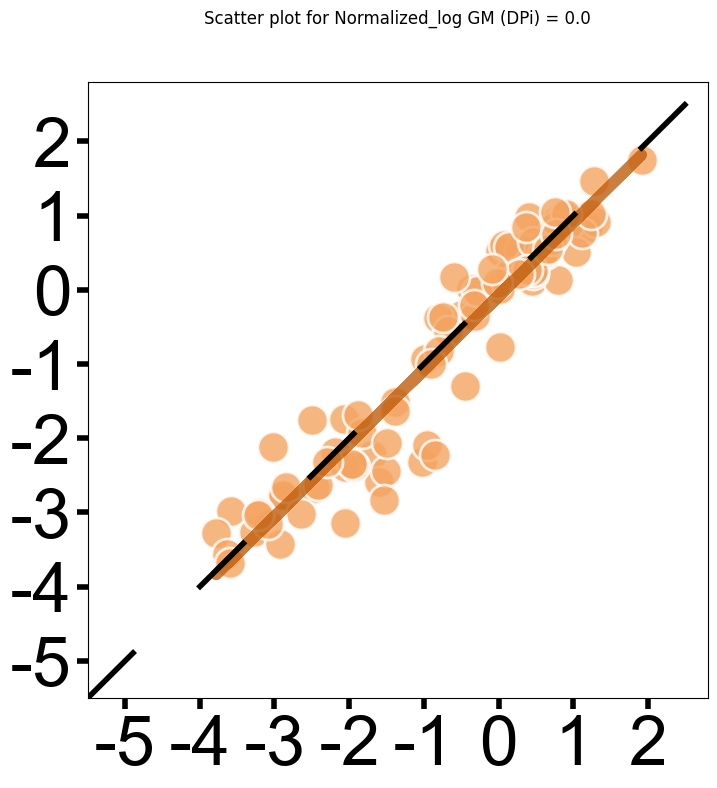

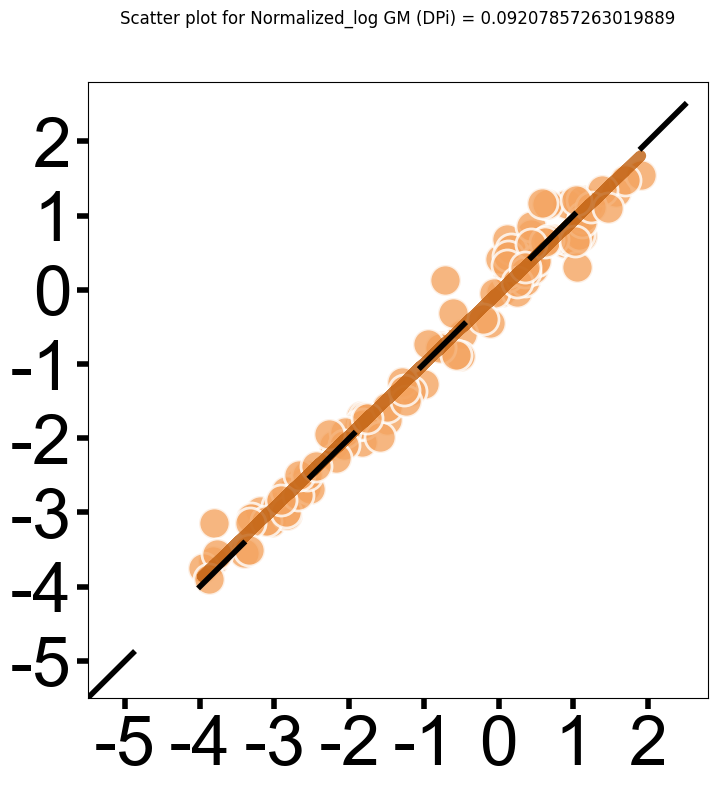

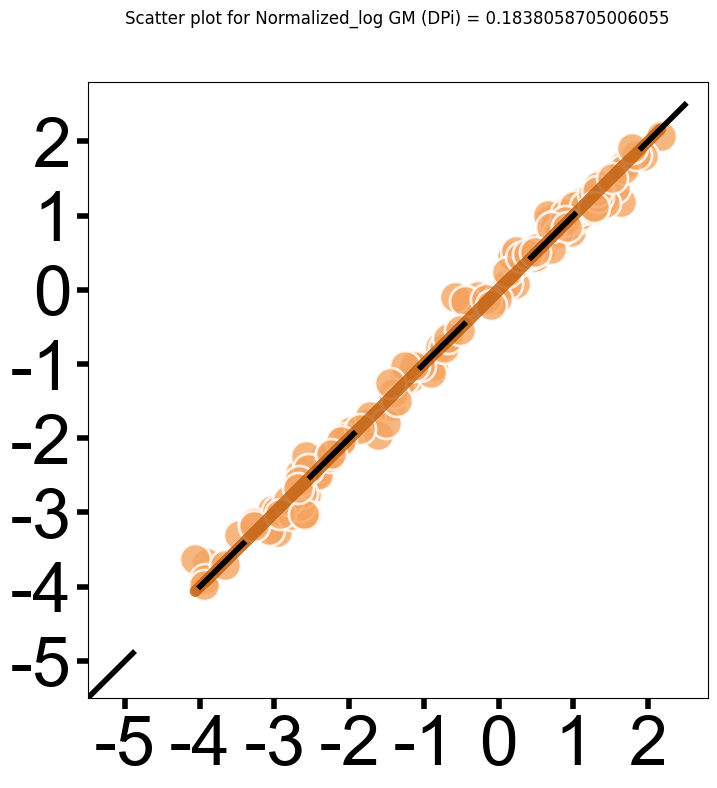

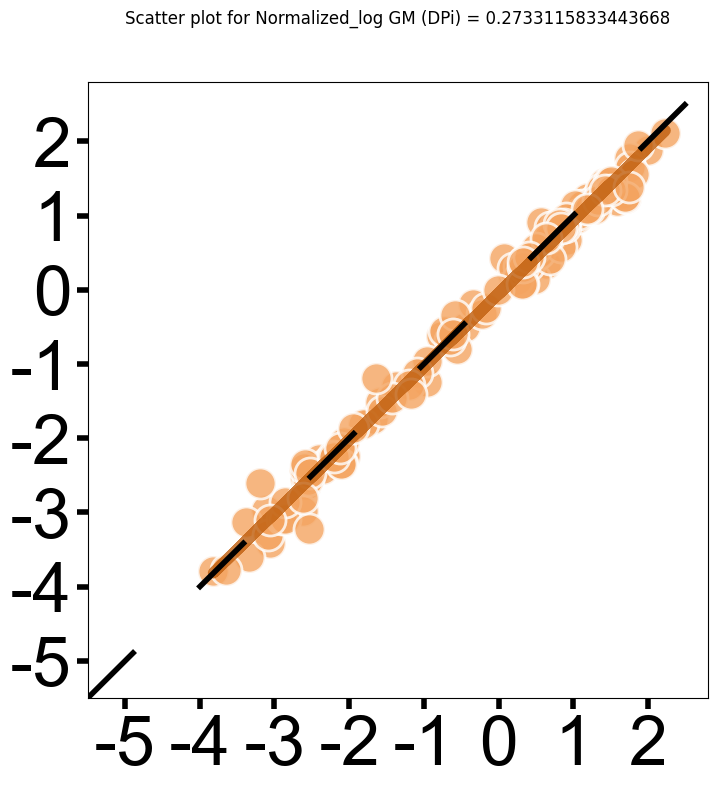

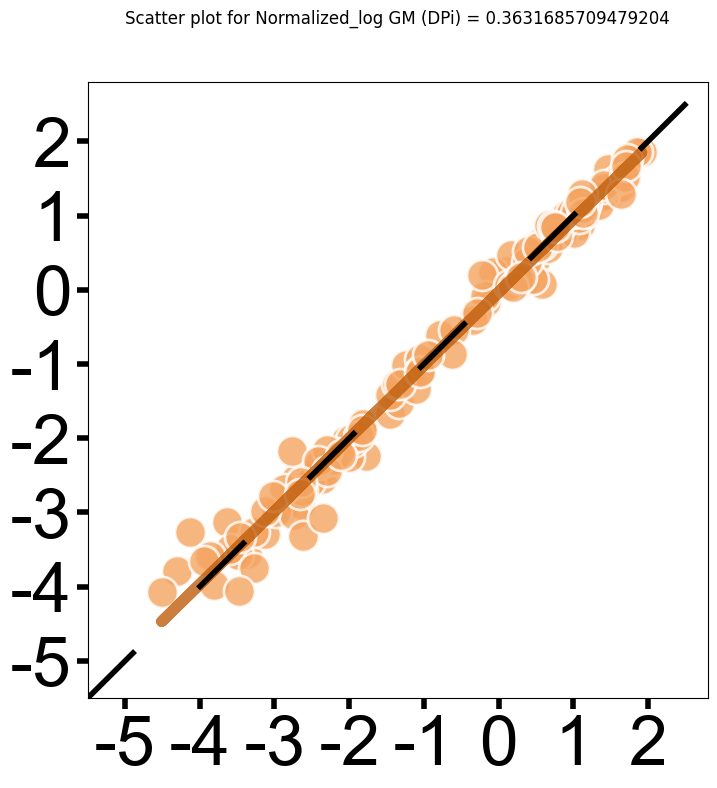

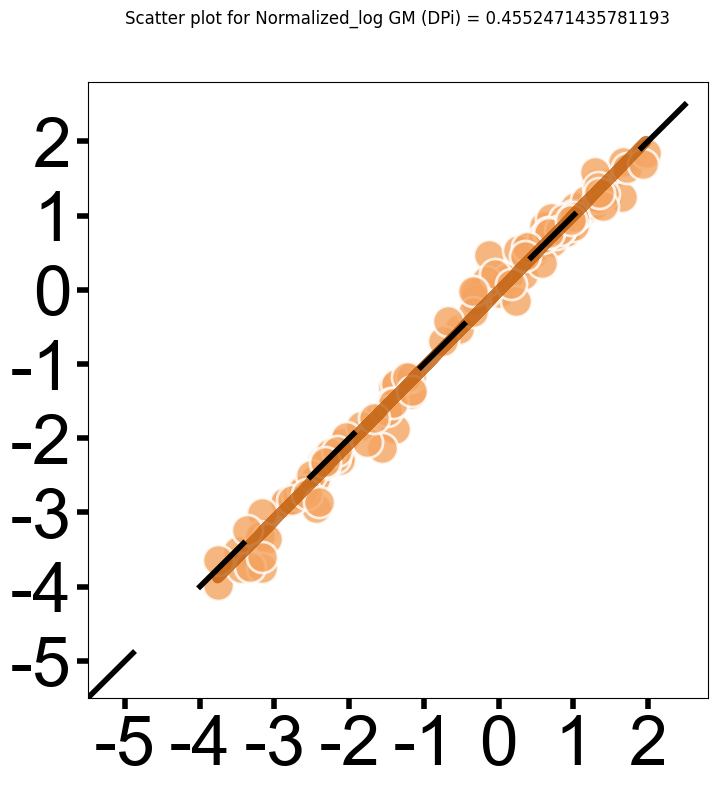

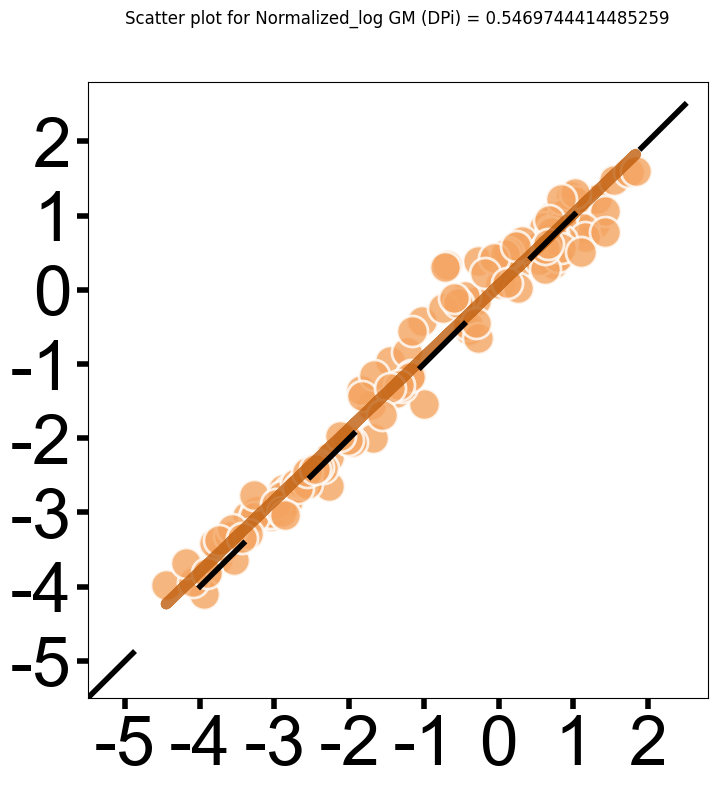

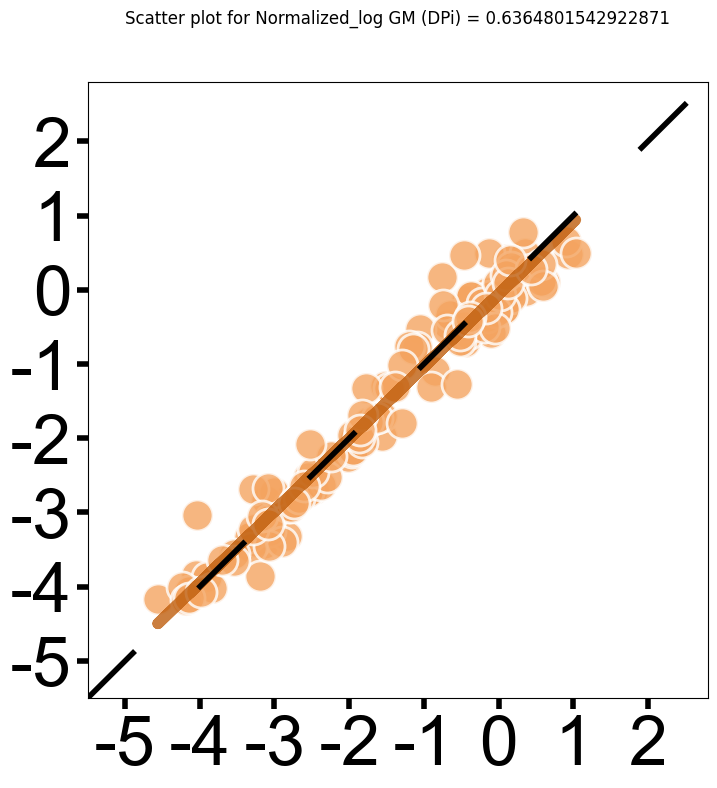

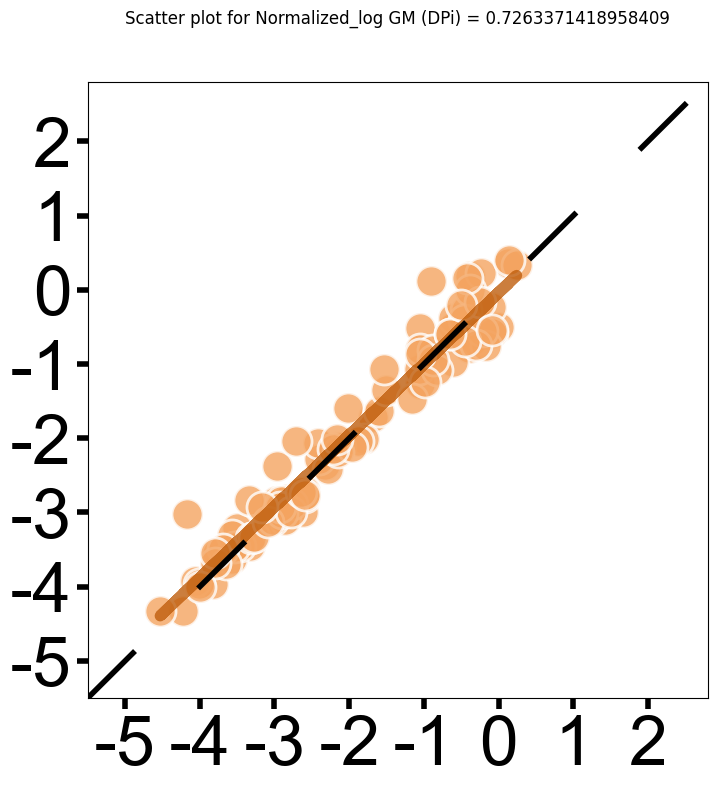

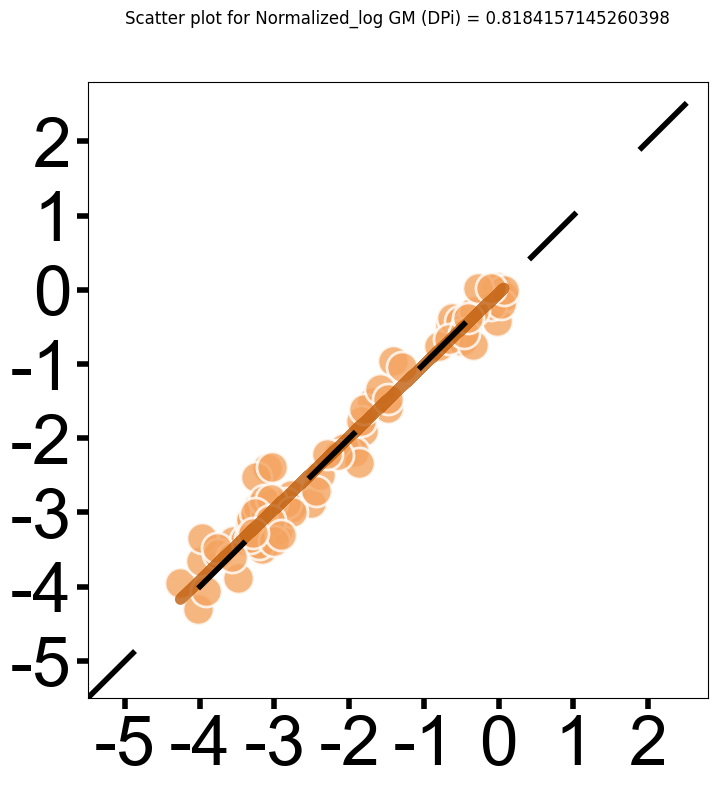

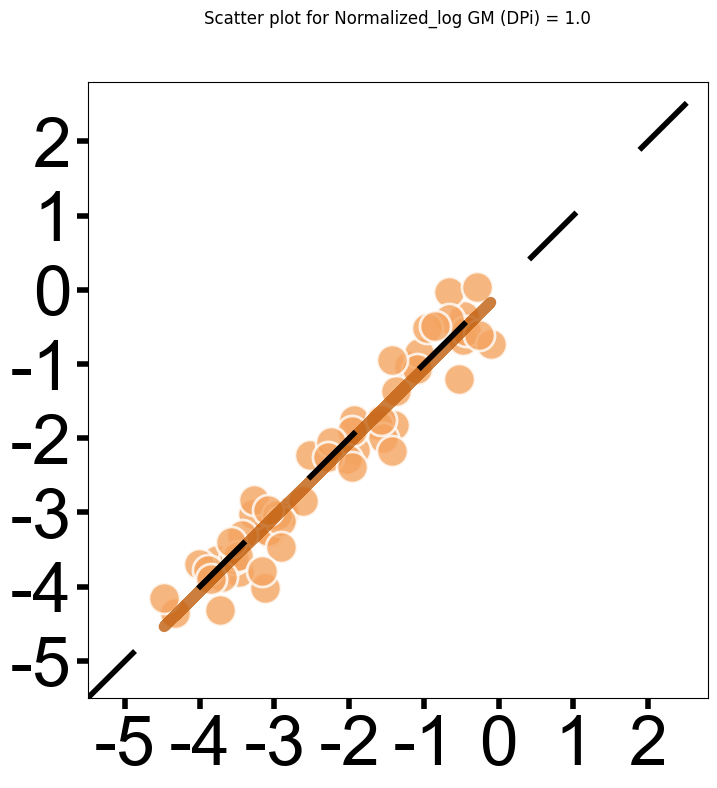

RFR For Normalized_log GM (DPi) = 0.0, R² = 0.899615529019895, RMSE = 0.4686390761366274
RFR For Normalized_log GM (DPi) = 0.09207857263019889, R² = 0.9770904460974414, RMSE = 0.24962320031446078
RFR For Normalized_log GM (DPi) = 0.1838058705006055, R² = 0.9905030100416313, RMSE = 0.16856524371002599
RFR For Normalized_log GM (DPi) = 0.2733115833443668, R² = 0.987688438378768, RMSE = 0.18410945021859385
RFR For Normalized_log GM (DPi) = 0.3631685709479204, R² = 0.9862153409228291, RMSE = 0.21436614252494612
RFR For Normalized_log GM (DPi) = 0.4552471435781193, R² = 0.9872168806853078, RMSE = 0.18907210103400687
RFR For Normalized_log GM (DPi) = 0.5469744414485259, R² = 0.9701950917105114, RMSE = 0.2973481501881901
RFR For Normalized_log GM (DPi) = 0.6364801542922871, R² = 0.9559396458157865, RMSE = 0.310365584805953
RFR For Normalized_log GM (DPi) = 0.7263371418958409, R² = 0.9484872668192277, RMSE = 0.3034864957600045
RFR For Normalized_log GM (DPi) = 0.8184157145260398, R² = 0.959040

In [5]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.legend as legend
from scipy.stats import linregress


df = pd.read_excel('preprocessed_input_data_6_features.xlsx')


target_column = 'log KPi'


y = df[target_column]
X = df.drop(columns=[target_column]) 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
particle_size = X_test['log GM (DPi)']

RFR = RandomForestRegressor(n_estimators=180, max_depth=130, max_features=8, min_samples_split=2, min_samples_leaf=1, random_state=42)
RFR.fit(X_train, y_train)
 
 
y_train_pred = RFR.predict(X_train)
y_test_pred = RFR.predict(X_test)

mse_test = mean_squared_error(y_test, y_test_pred) 
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)   
print(f"R^2 Score_test: {r2_test}")
print(f"Root Mean Squared Error_test: {rmse_test}") 

  
df_1 = pd.DataFrame({'particle size': particle_size, 'y_test': y_test, 'y_test_pred': y_test_pred})

metrics = {}  
  
 
for value in np.unique(particle_size):  
    subset = df_1[df_1['particle size'] == value]  
    y_true_subset = subset['y_test'].values  
    y_pred_subset = subset['y_test_pred'].values  
      
    
    r2 = r2_score(y_true_subset, y_pred_subset)  
      
    
    rmse = np.sqrt(mean_squared_error(y_true_subset, y_pred_subset))  
      
      
    metrics[value] = {'r2': r2, 'rmse': rmse}  
      
     
    plt.figure(figsize=(8, 8)) 
     
    plt.scatter(y_true_subset, y_pred_subset, color='#F4A460', alpha=0.8, s=500, edgecolors='white', linewidths=2)
    plt.xlim(-5.5, 2.8)
    plt.ylim(-5.5, 2.8)
    
     
    plt.xticks(ticks=[-5, -4, -3, -2, -1, 0, 1, 2], labels=[-5, -4, -3, -2, -1, 0, 1, 2], fontdict={'family': 'Arial', 'size': 50})  
  
     
    plt.yticks(ticks=[-5, -4, -3, -2, -1, 0, 1, 2], labels=[-5, -4, -3, -2, -1, 0, 1, 2], fontdict={'family': 'Arial', 'size': 50})  
    
      
    plt.tick_params(axis='both', which='major', length=8, width=4)

    slope_test, intercept_test, r_value_test, p_value_test, std_err_test = linregress(y_true_subset, y_pred_subset)
    line_test_fit = plt.plot(y_true_subset, slope_test * y_true_subset + intercept_test, color='#BF5E0D', linestyle='solid', alpha=0.8, linewidth=8)
    
    
    x_line = np.linspace(-5.5, 2.8, 100)
    y_line = x_line
    
    line, =plt.plot(x_line, y_line, color='#000000', linestyle='--', linewidth=4)
    line.set_dashes([12, 16])
    
    plt.title(f'Scatter plot for Normalized_log GM (DPi) = {value}', loc='center', pad=20, y=1.05) 
    
    plt.show()
  
 
for value, metric in metrics.items():  
    print(f'RFR For Normalized_log GM (DPi) = {value}, R² = {metric["r2"]}, RMSE = {metric["rmse"]}')

R^2 Score_test: 0.9499363691148912
Root Mean Squared Error_test: 0.38281004351932774


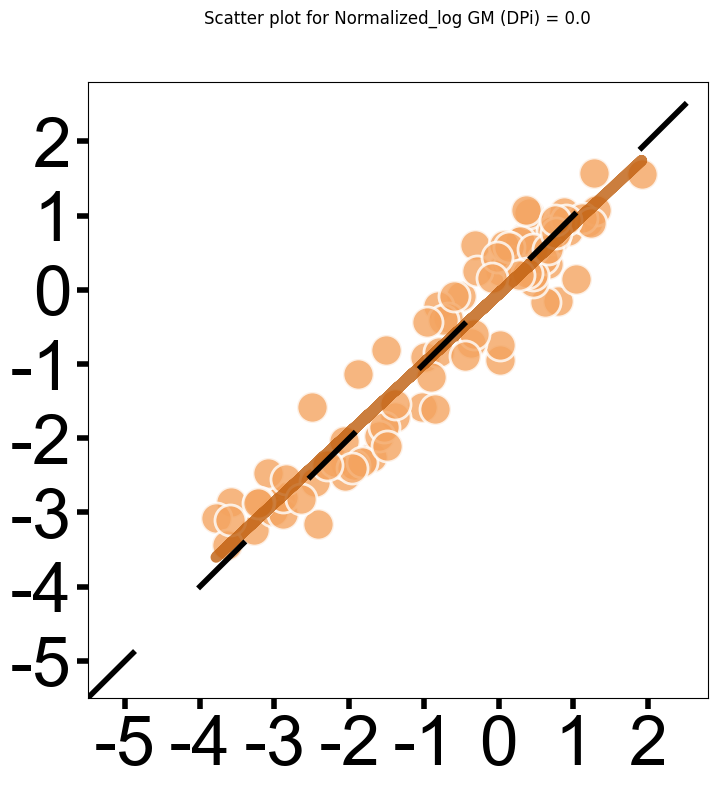

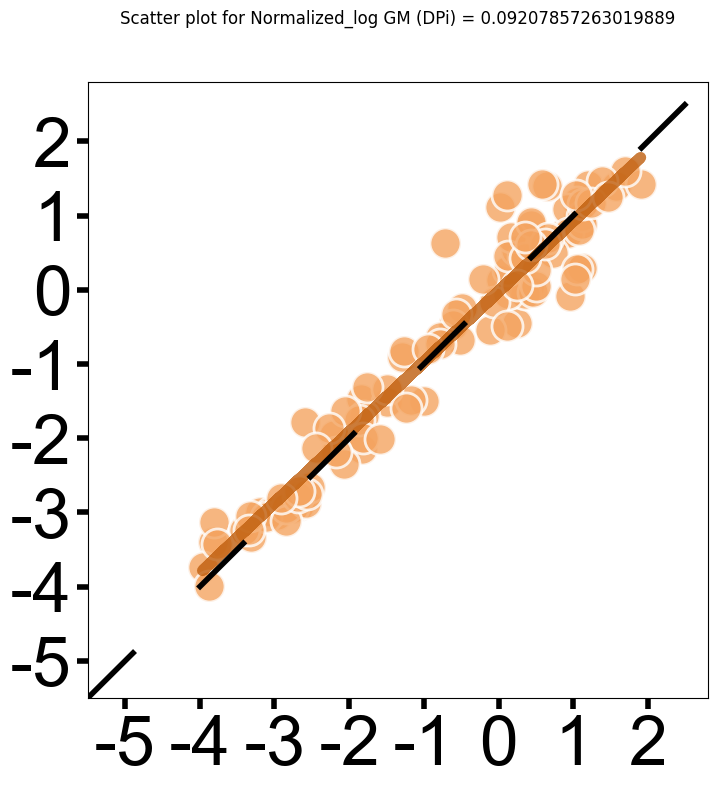

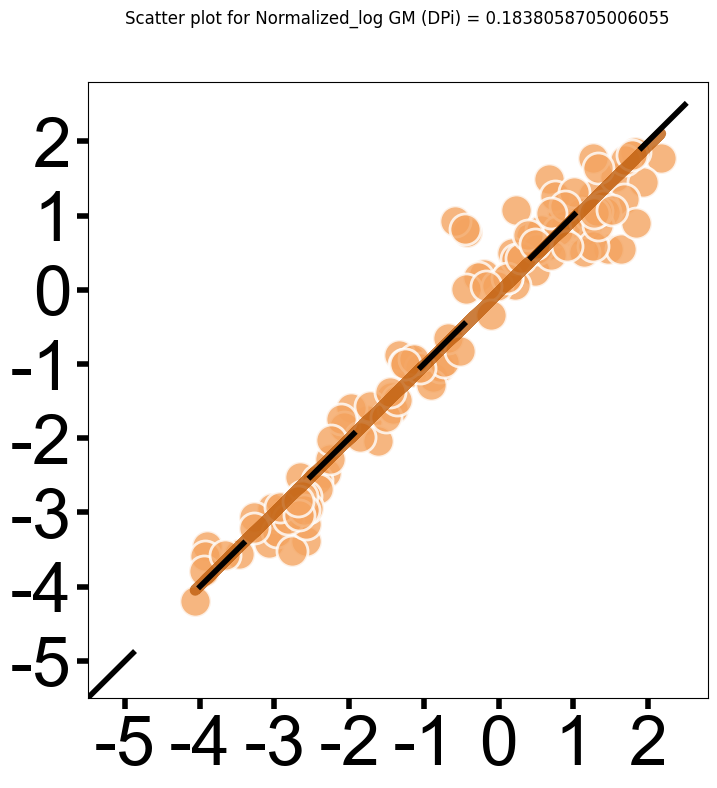

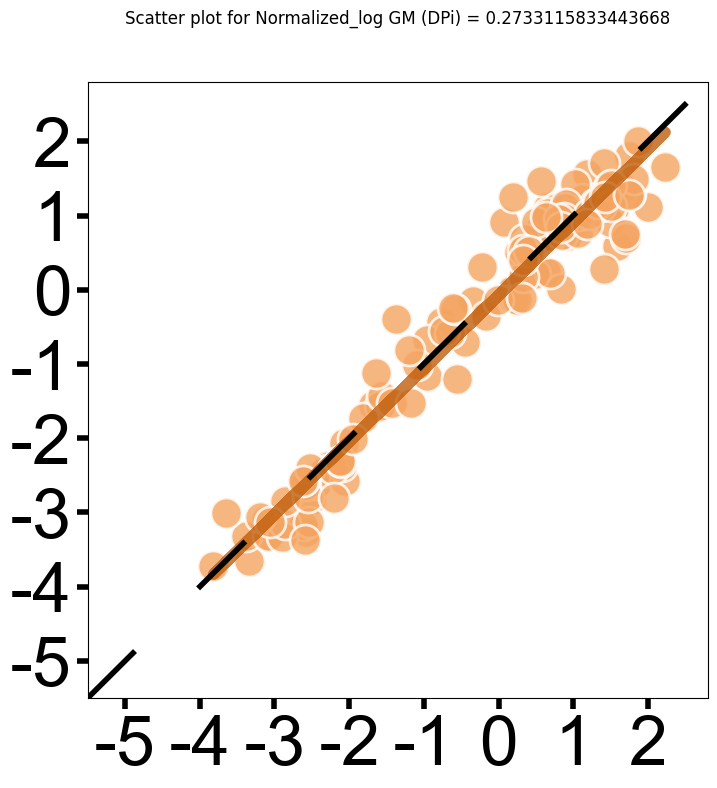

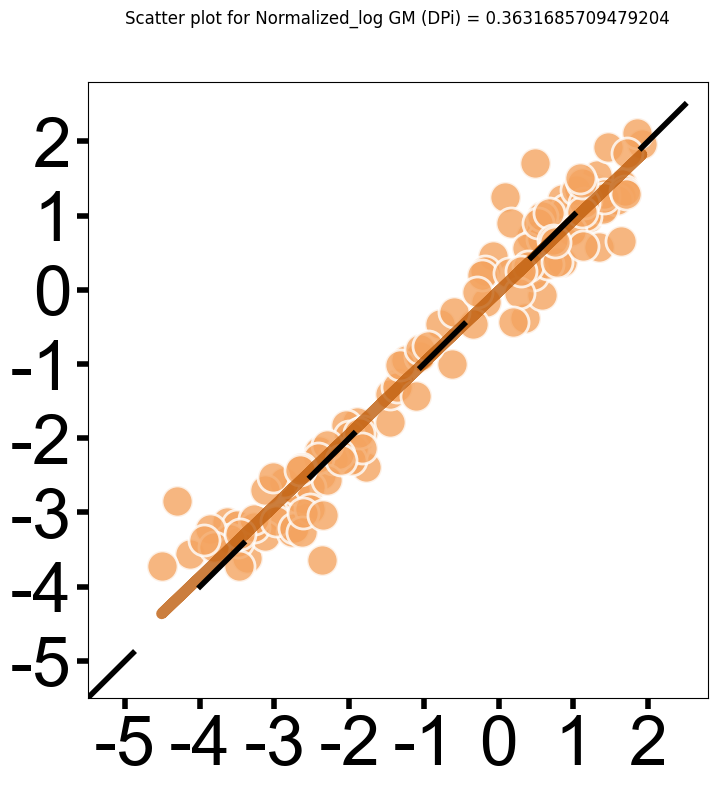

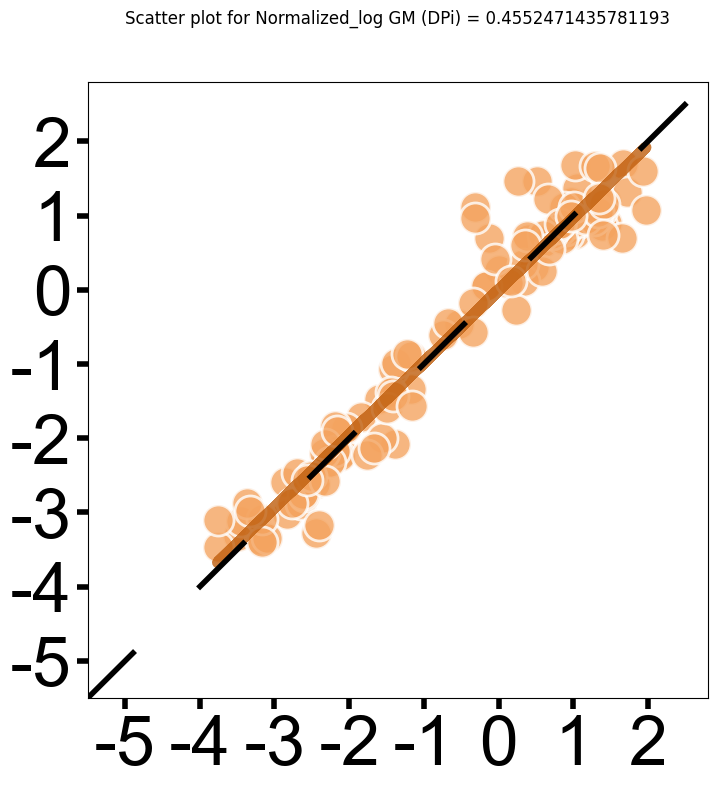

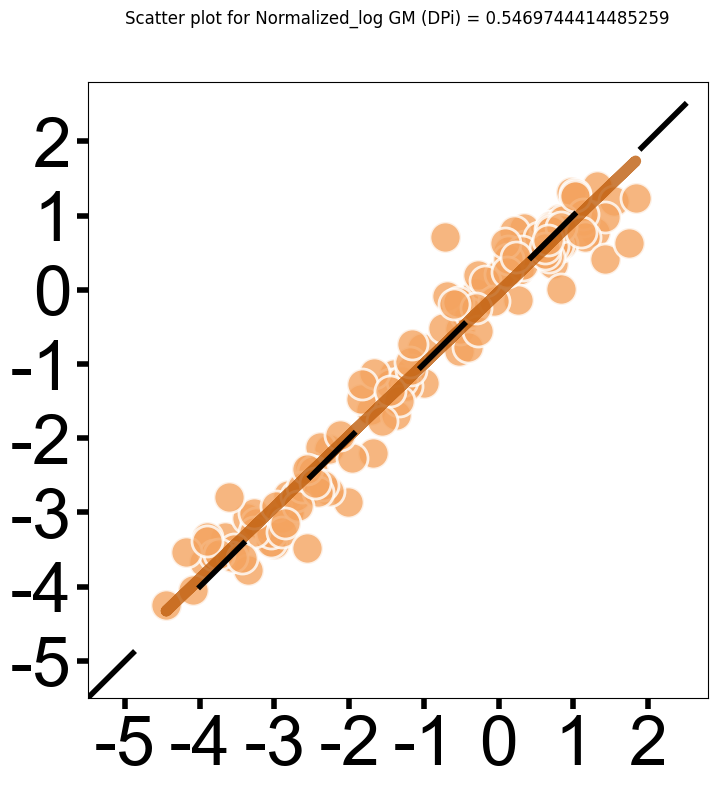

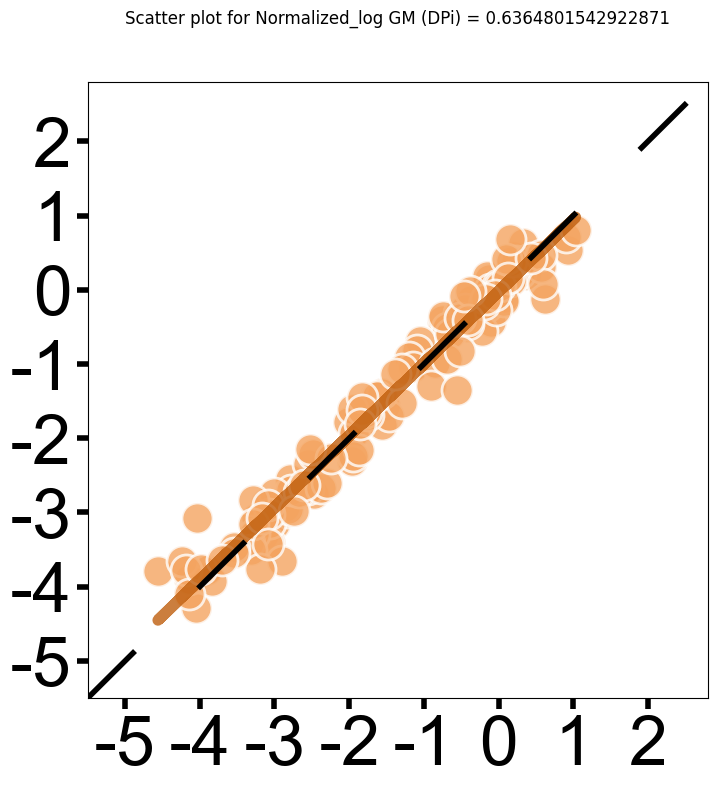

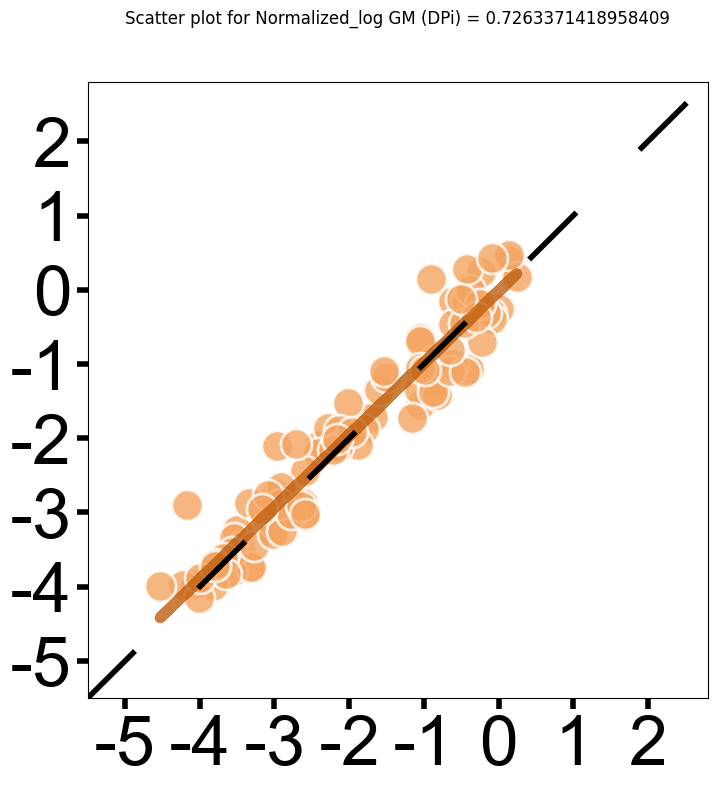

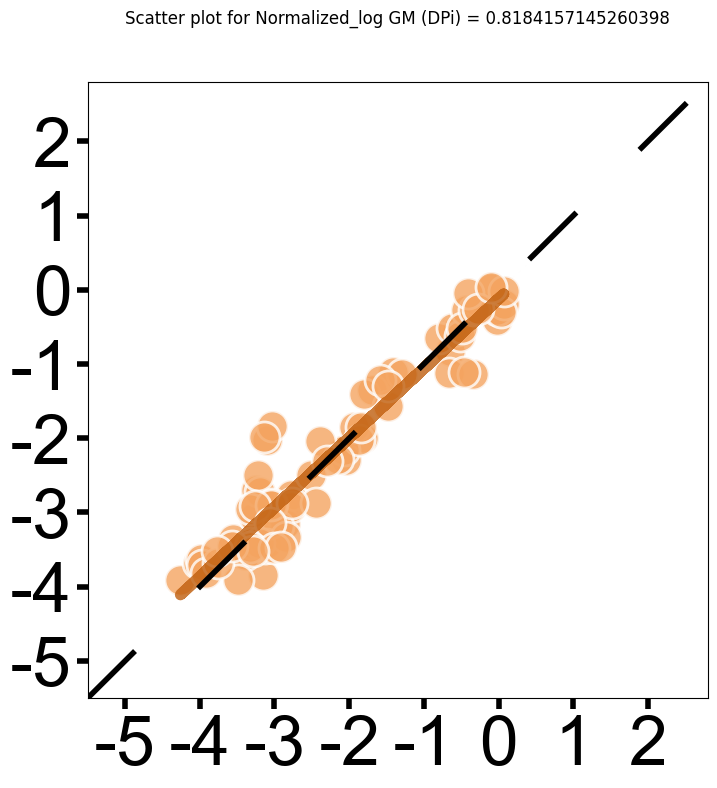

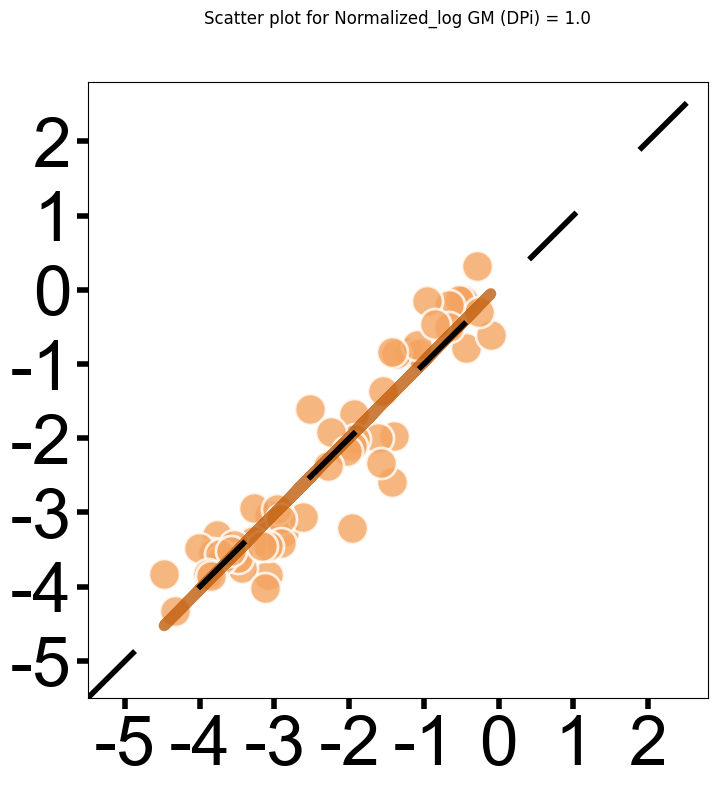

SVR For Normalized_log GM (DPi) = 0.0, R² = 0.9104534014785659, RMSE = 0.4426187197325017
SVR For Normalized_log GM (DPi) = 0.09207857263019889, R² = 0.9395758035898617, RMSE = 0.4053984390645867
SVR For Normalized_log GM (DPi) = 0.1838058705006055, R² = 0.9476425115305744, RMSE = 0.39578966199819415
SVR For Normalized_log GM (DPi) = 0.2733115833443668, R² = 0.9433973692377476, RMSE = 0.3947642518140725
SVR For Normalized_log GM (DPi) = 0.3631685709479204, R² = 0.954209399989242, RMSE = 0.39070263958906315
SVR For Normalized_log GM (DPi) = 0.4552471435781193, R² = 0.9468351156901644, RMSE = 0.38558618518251975
SVR For Normalized_log GM (DPi) = 0.5469744414485259, R² = 0.9573177746558112, RMSE = 0.355831894888827
SVR For Normalized_log GM (DPi) = 0.6364801542922871, R² = 0.9632509761854557, RMSE = 0.2834473947967365
SVR For Normalized_log GM (DPi) = 0.7263371418958409, R² = 0.9266520138394918, RMSE = 0.3621397283681548
SVR For Normalized_log GM (DPi) = 0.8184157145260398, R² = 0.9157275

In [6]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.legend as legend
from scipy.stats import linregress


df = pd.read_excel('preprocessed_input_data_6_features.xlsx')


target_column = 'log KPi'


y = df[target_column]
X = df.drop(columns=[target_column]) 

 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
particle_size = X_test['log GM (DPi)']

svr = SVR(C=1200, epsilon=0.2, gamma=3)
svr.fit(X_train, y_train)
 

y_train_pred = svr.predict(X_train)
y_test_pred = svr.predict(X_test)

mse_test = mean_squared_error(y_test, y_test_pred) 
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)   
print(f"R^2 Score_test: {r2_test}")
print(f"Root Mean Squared Error_test: {rmse_test}") 


df_1 = pd.DataFrame({'particle size': particle_size, 'y_test': y_test, 'y_test_pred': y_test_pred})

metrics = {}  
  

for value in np.unique(particle_size):  
    subset = df_1[df_1['particle size'] == value]  
    y_true_subset = subset['y_test'].values  
    y_pred_subset = subset['y_test_pred'].values  
      
      
    r2 = r2_score(y_true_subset, y_pred_subset)  
      
      
    rmse = np.sqrt(mean_squared_error(y_true_subset, y_pred_subset))  
      
      
    metrics[value] = {'r2': r2, 'rmse': rmse}  
      
      
    plt.figure(figsize=(8, 8)) 
      
    plt.scatter(y_true_subset, y_pred_subset, color='#F4A460', alpha=0.8, s=500, edgecolors='white', linewidths=2)
    plt.xlim(-5.5, 2.8)
    plt.ylim(-5.5, 2.8)
    
      
    plt.xticks(ticks=[-5, -4, -3, -2, -1, 0, 1, 2], labels=[-5, -4, -3, -2, -1, 0, 1, 2], fontdict={'family': 'Arial', 'size': 50})  
  
     
    plt.yticks(ticks=[-5, -4, -3, -2, -1, 0, 1, 2], labels=[-5, -4, -3, -2, -1, 0, 1, 2], fontdict={'family': 'Arial', 'size': 50})  
    
      
    plt.tick_params(axis='both', which='major', length=8, width=4)

    slope_test, intercept_test, r_value_test, p_value_test, std_err_test = linregress(y_true_subset, y_pred_subset)
    line_test_fit = plt.plot(y_true_subset, slope_test * y_true_subset + intercept_test, color='#BF5E0D', linestyle='solid', alpha=0.8, linewidth=8)
    
    
    x_line = np.linspace(-5.5, 2.8, 100)
    y_line = x_line
    
    line, =plt.plot(x_line, y_line, color='#000000', linestyle='--', linewidth=4)
    line.set_dashes([12, 16])
    
    plt.title(f'Scatter plot for Normalized_log GM (DPi) = {value}', loc='center', pad=20, y=1.05) 
    
    plt.show()  
  
 
for value, metric in metrics.items():  
    print(f'SVR For Normalized_log GM (DPi) = {value}, R² = {metric["r2"]}, RMSE = {metric["rmse"]}')

38/38 [==============================] - 0s 1ms/step
R^2 Score_test: 0.9484276592078174
Root Mean Squared Error_test: 0.3885353816077022


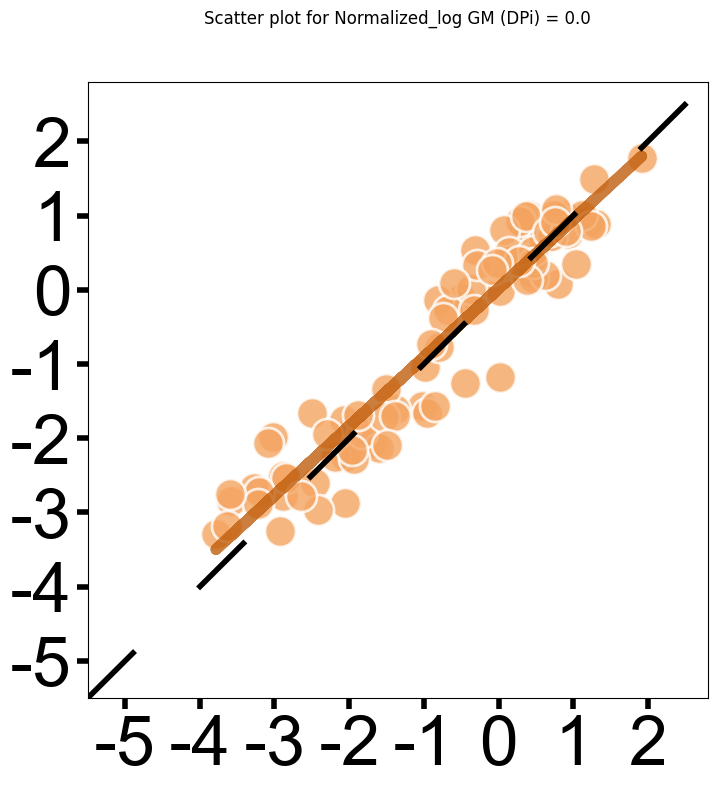

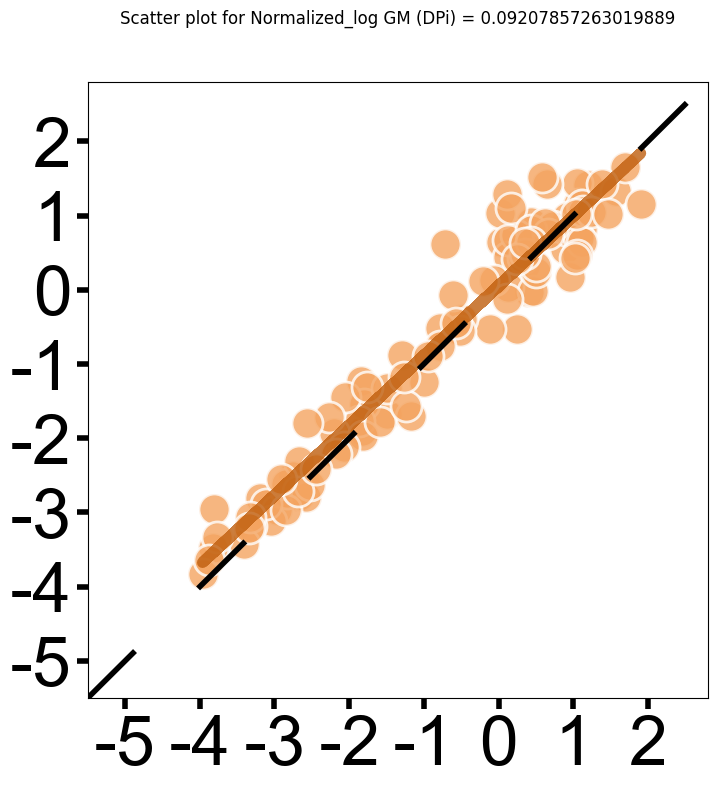

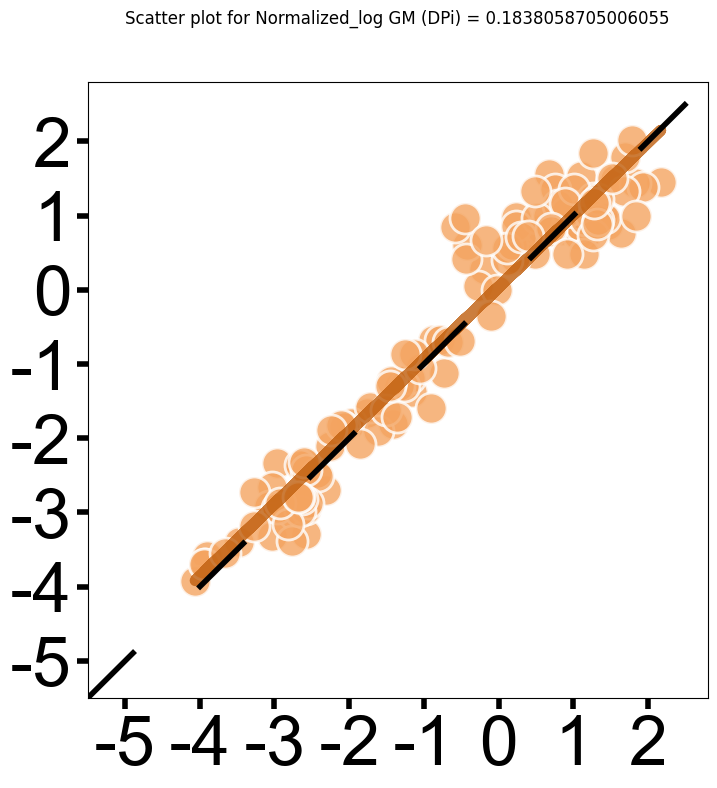

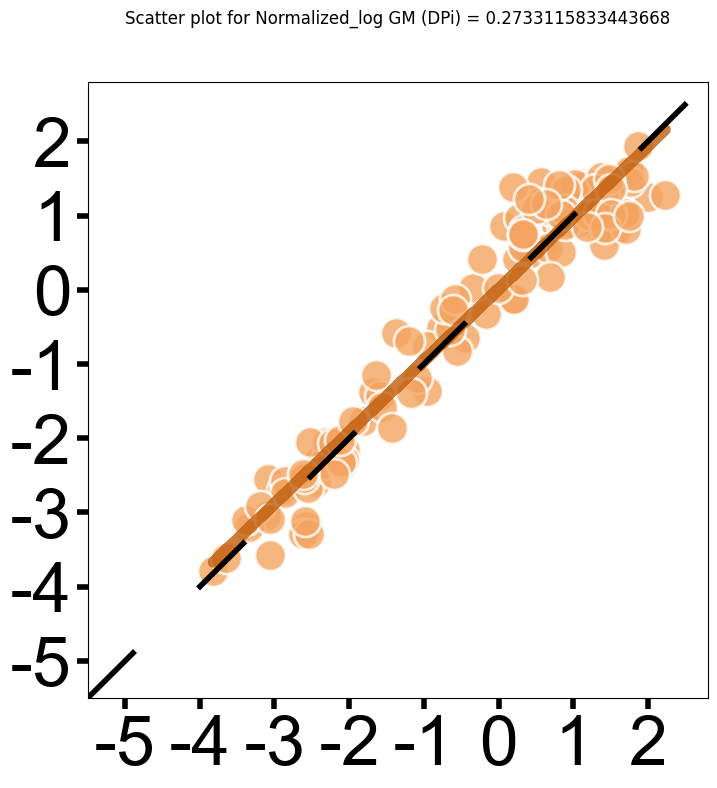

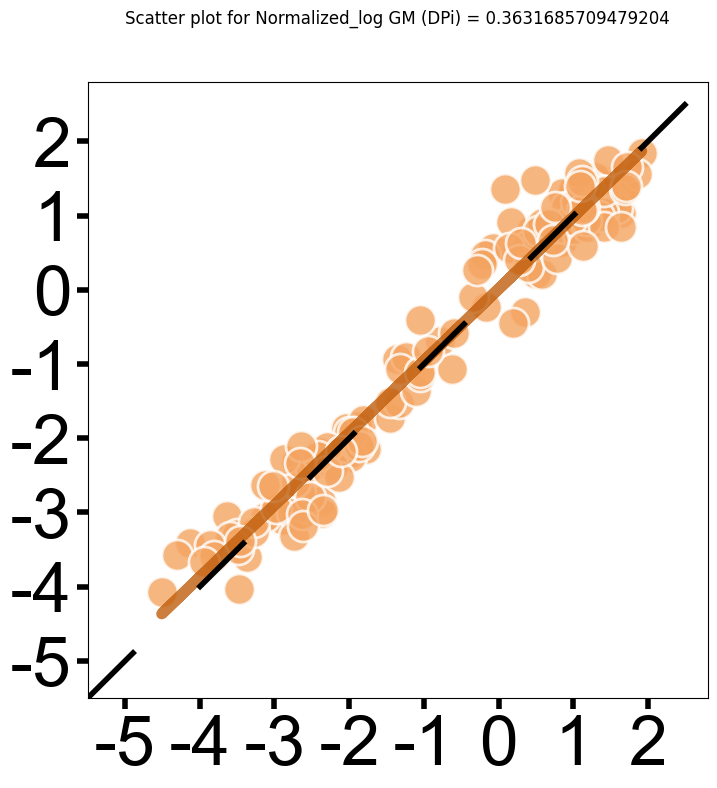

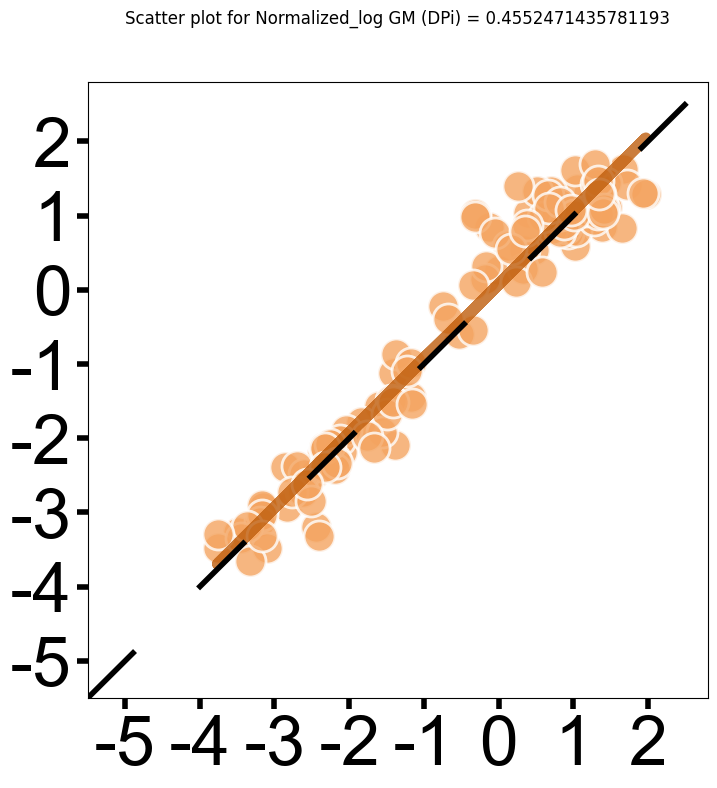

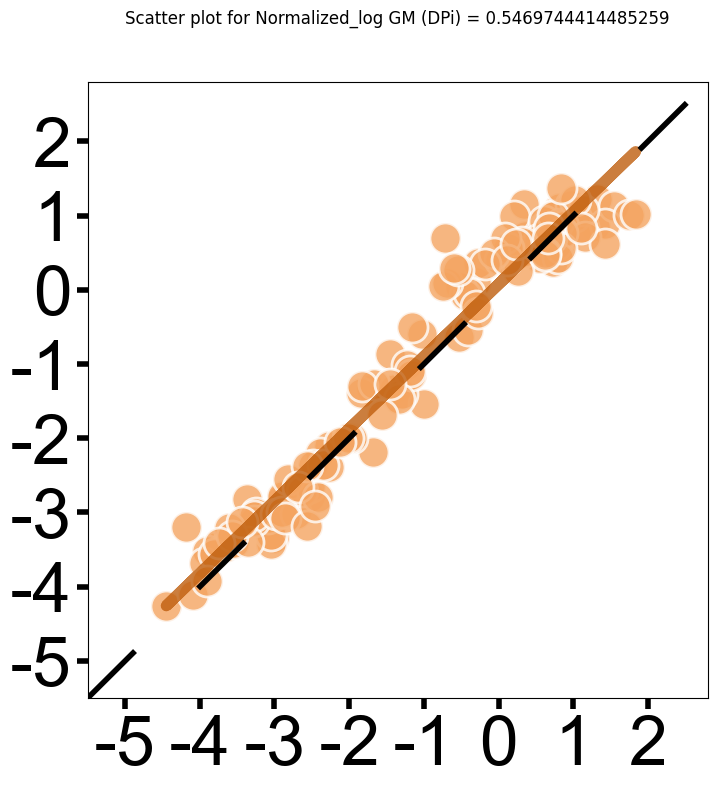

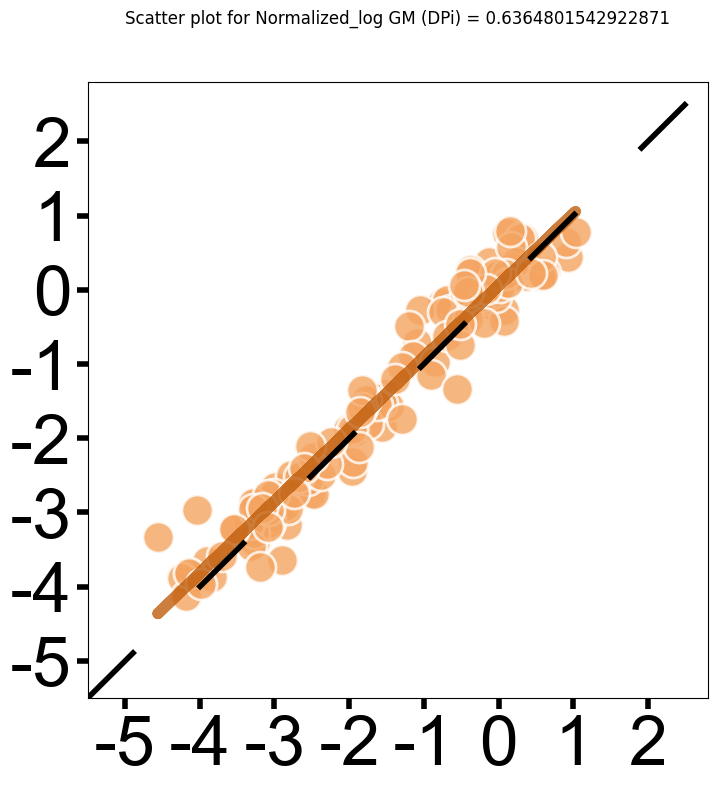

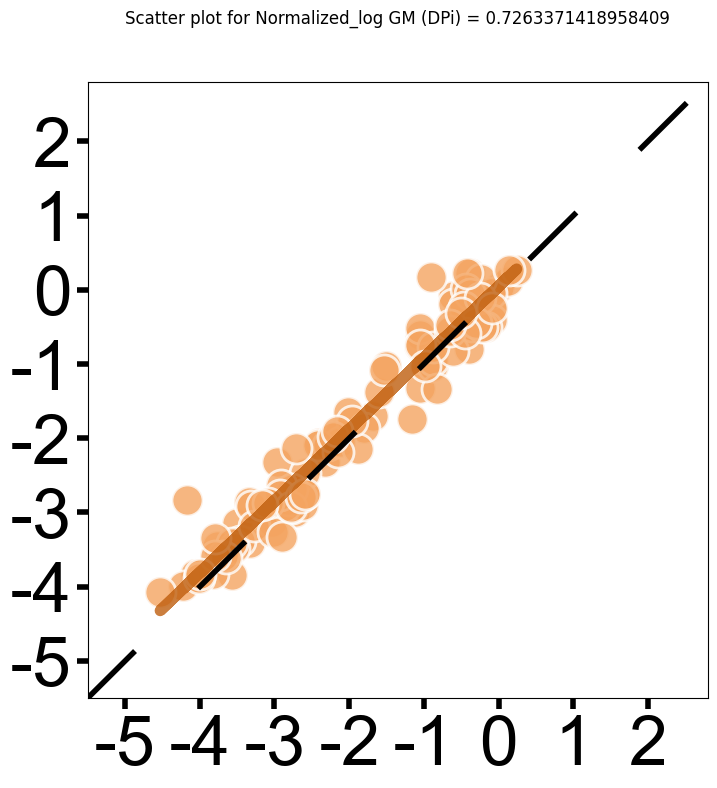

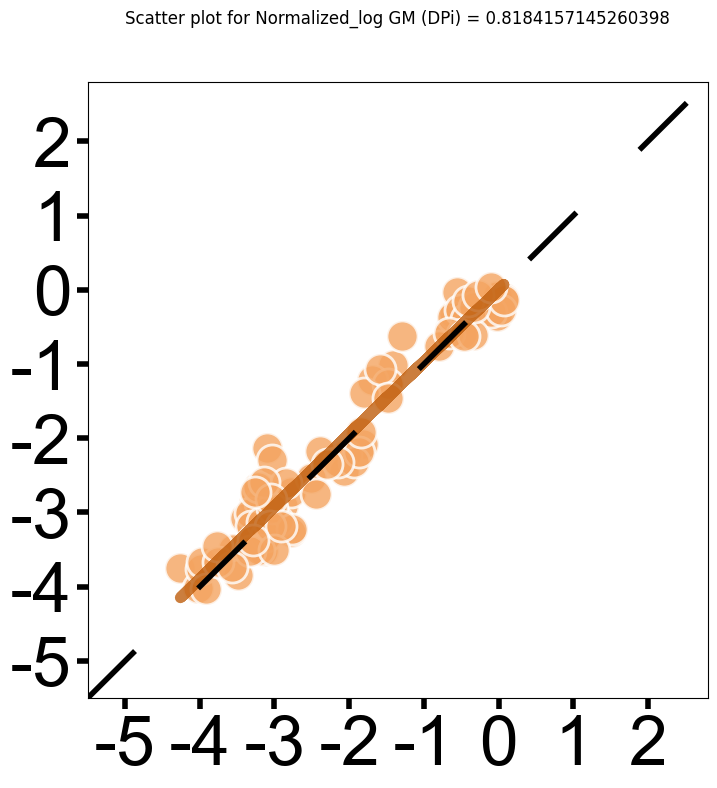

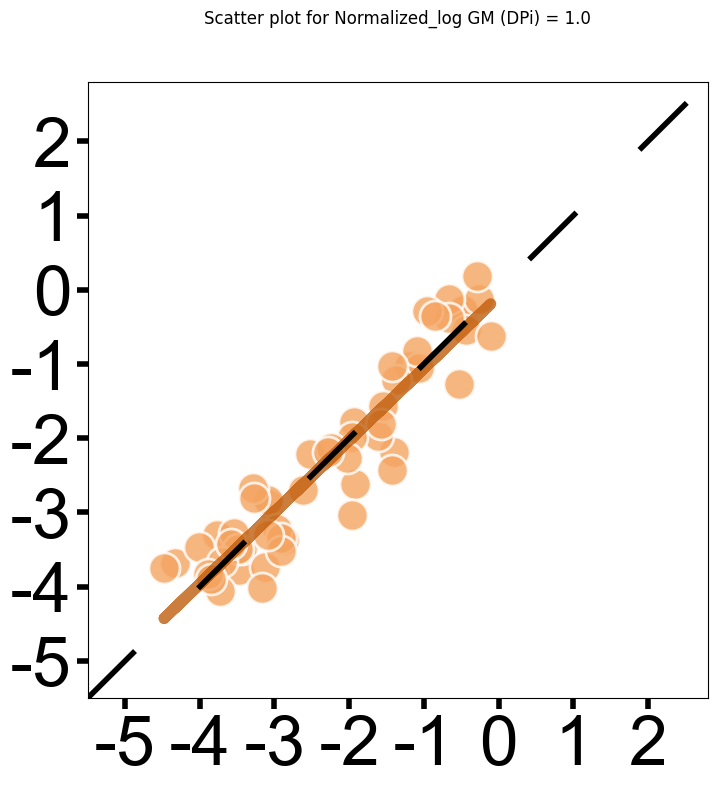

DNN For Normalized_log GM (DPi) = 0.0, R² = 0.9019462877874144, RMSE = 0.46316661824984645
DNN For Normalized_log GM (DPi) = 0.09207857263019889, R² = 0.9384227563884084, RMSE = 0.4092481763164931
DNN For Normalized_log GM (DPi) = 0.1838058705006055, R² = 0.9404828202083108, RMSE = 0.4219842243812109
DNN For Normalized_log GM (DPi) = 0.2733115833443668, R² = 0.9399448986426638, RMSE = 0.4066253608564448
DNN For Normalized_log GM (DPi) = 0.3631685709479204, R² = 0.960196737579931, RMSE = 0.3642650575313265
DNN For Normalized_log GM (DPi) = 0.4552471435781193, R² = 0.9443411244218838, RMSE = 0.3945265576943096
DNN For Normalized_log GM (DPi) = 0.5469744414485259, R² = 0.9511040007326882, RMSE = 0.3808535509773929
DNN For Normalized_log GM (DPi) = 0.6364801542922871, R² = 0.9458838607806048, RMSE = 0.34396398259515887
DNN For Normalized_log GM (DPi) = 0.7263371418958409, R² = 0.9385539308719407, RMSE = 0.33145847422404107
DNN For Normalized_log GM (DPi) = 0.8184157145260398, R² = 0.936769

In [7]:
import random
import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)  
tf.random.set_seed(42)

import pandas as pd
import os
from tensorflow import keras
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Dense  
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.legend as legend
from scipy.stats import linregress

os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'


df = pd.read_excel('preprocessed_input_data_6_features.xlsx')


target_column = 'log KPi'

 
y = df[target_column]
X = df.drop(columns=[target_column]) 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
particle_size = X_test['log GM (DPi)']

 
DNN = Sequential([  
  Dense(64, activation='relu', input_shape=(X.shape[1],)), 
  Dense(32, activation='relu'),
  Dense(1)
])  


DNN.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

  
DNN.fit(X_train, y_train, epochs=1000, batch_size=64, shuffle=False, verbose=0)  
  

y_train_pred = DNN.predict(X_train)
y_test_pred = DNN.predict(X_test)
 

y_train_pred_flattened = y_train_pred.flatten()
y_test_pred_flattened = y_test_pred.flatten()

mse_test = mean_squared_error(y_test, y_test_pred_flattened) 
r2_test = r2_score(y_test, y_test_pred_flattened)
rmse_test = np.sqrt(mse_test)   
print(f"R^2 Score_test: {r2_test}")
print(f"Root Mean Squared Error_test: {rmse_test}") 

  
df_1 = pd.DataFrame({'particle size': particle_size, 'y_test': y_test, 'y_test_pred_flattened': y_test_pred_flattened})

metrics = {}  
  
  
for value in np.unique(particle_size):  
    subset = df_1[df_1['particle size'] == value]  
    y_true_subset = subset['y_test'].values  
    y_pred_subset = subset['y_test_pred_flattened'].values  
      
      
    r2 = r2_score(y_true_subset, y_pred_subset)  
      
      
    rmse = np.sqrt(mean_squared_error(y_true_subset, y_pred_subset))  
      
     
    metrics[value] = {'r2': r2, 'rmse': rmse}  
      
      
    plt.figure(figsize=(8, 8)) 
    
    plt.scatter(y_true_subset, y_pred_subset, color='#F4A460', alpha=0.8, s=500, edgecolors='white', linewidths=2)
    plt.xlim(-5.5, 2.8)
    plt.ylim(-5.5, 2.8)
    
      
    plt.xticks(ticks=[-5, -4, -3, -2, -1, 0, 1, 2], labels=[-5, -4, -3, -2, -1, 0, 1, 2], fontdict={'family': 'Arial', 'size': 50})  
  
      
    plt.yticks(ticks=[-5, -4, -3, -2, -1, 0, 1, 2], labels=[-5, -4, -3, -2, -1, 0, 1, 2], fontdict={'family': 'Arial', 'size': 50})  
    
      
    plt.tick_params(axis='both', which='major', length=8, width=4)

    slope_test, intercept_test, r_value_test, p_value_test, std_err_test = linregress(y_true_subset, y_pred_subset)
    line_test_fit = plt.plot(y_true_subset, slope_test * y_true_subset + intercept_test, color='#BF5E0D', linestyle='solid', alpha=0.8, linewidth=8)
    
    
    x_line = np.linspace(-5.5, 2.8, 100)
    y_line = x_line
    
    line, =plt.plot(x_line, y_line, color='#000000', linestyle='--', linewidth=4)
    line.set_dashes([12, 16])
    
    plt.title(f'Scatter plot for Normalized_log GM (DPi) = {value}', loc='center', pad=20, y=1.05) 
    
    plt.show()  
  
  
for value, metric in metrics.items():  
    print(f'DNN For Normalized_log GM (DPi) = {value}, R² = {metric["r2"]}, RMSE = {metric["rmse"]}')